<a href="https://colab.research.google.com/github/Roshan0505/Text-Classification-of-Human-vs-AI/blob/main/GENERAL_HEALTH_PREDICTION_FROM_CVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [15]:
df = pd.read_csv('CVD_cleaned.csv')
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [16]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  int64  
 12  Weight_(kg)                   308854 non-nul

,0
General_Health,0
Checkup,0
Exercise,0
Heart_Disease,0
Skin_Cancer,0
Other_Cancer,0
Depression,0
Diabetes,0
Arthritis,0
Sex,0


In [17]:
df = df.dropna()

In [18]:
df.isnull().sum()

,0
General_Health,0
Checkup,0
Exercise,0
Heart_Disease,0
Skin_Cancer,0
Other_Cancer,0
Depression,0
Diabetes,0
Arthritis,0
Sex,0


In [19]:
df['Heart_Disease'].unique()

array(['No', 'Yes'], dtype=object)

In [20]:
df['Heart_Disease'] = df['Heart_Disease'].map({'Yes':1, 'No':0})

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 38 columns):
 #   Column                                               Non-Null Count   Dtype  
---  ------                                               --------------   -----  
 0   Heart_Disease                                        308854 non-null  int64  
 1   Height_(cm)                                          308854 non-null  int64  
 2   Weight_(kg)                                          308854 non-null  float64
 3   BMI                                                  308854 non-null  float64
 4   Alcohol_Consumption                                  308854 non-null  int64  
 5   Fruit_Consumption                                    308854 non-null  int64  
 6   Green_Vegetables_Consumption                         308854 non-null  int64  
 7   FriedPotato_Consumption                              308854 non-null  int64  
 8   General_Health_Fair                                  3

In [23]:
df = pd.read_csv('CVD_cleaned.csv')
df = df.dropna()
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [25]:
df['Heart_Disease'] = df['Heart_Disease'].map({'Yes':1, 'No':0})

In [27]:
df['Heart_Disease'].value_counts()

,count
Heart_Disease,


In [28]:
df['Heart_Disease'].unique()

array([nan])

In [2]:
import pandas as pd

df = pd.read_csv('CVD_cleaned.csv')
df = df.dropna()

df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [3]:
df['Heart_Disease'].unique()

array(['No', 'Yes'], dtype=object)

In [4]:
df['Heart_Disease'] = df['Heart_Disease'].map({'No':0, 'Yes':1})

In [5]:
df['Heart_Disease'].value_counts()

,count
Heart_Disease,
0,283883
1,24971


In [7]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,0,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,1,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,0,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,1,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,0,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [8]:
df['Heart_Disease'] = df['Heart_Disease'].map({'No':0, 'Yes':1})

In [9]:
df['Heart_Disease'].value_counts()

,count
Heart_Disease,


In [10]:
X = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

In [11]:
X = pd.get_dummies(X, drop_first=True)
X = X.astype(int)

In [13]:
y.isnull().sum()

np.int64(308854)

In [1]:
import pandas as pd

df = pd.read_csv('CVD_cleaned.csv')

print(df.shape)
print(df['Heart_Disease'].unique())

(308854, 19)
['No' 'Yes']


In [2]:
df['Heart_Disease'] = df['Heart_Disease'].replace({'No':0, 'Yes':1})

/tmp/ipython-input-6750/709101827.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Heart_Disease'] = df['Heart_Disease'].replace({'No':0, 'Yes':1})


In [3]:
df['Heart_Disease'].unique()

array([0, 1])

In [4]:
df['Heart_Disease'].isnull().sum()

np.int64(0)

In [10]:
df = df.dropna()

In [11]:
X = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

In [12]:
y.isnull().sum()

np.int64(0)

In [13]:
X = pd.get_dummies(X, drop_first=True)
X = X.astype(int)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (247083, 37)
X_test shape: (61771, 37)
y_train shape: (247083,)
y_test shape: (61771,)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


Logistic Regression Accuracy: 0.7383885642129802

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.73      0.84     56777
           1       0.21      0.80      0.33      4994

    accuracy                           0.74     61771
   macro avg       0.59      0.77      0.58     61771
weighted avg       0.91      0.74      0.80     61771



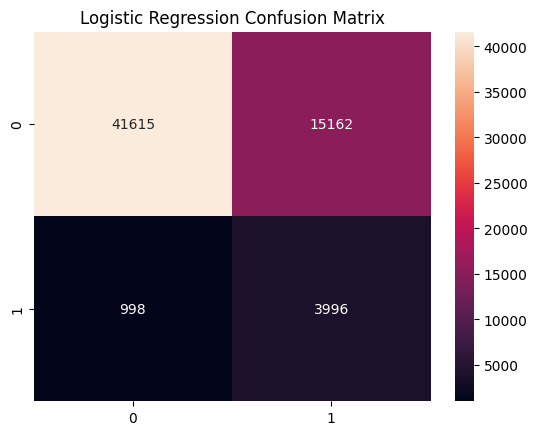

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\nClassification Report:\n", classification_report(y_test, log_pred))

cm = confusion_matrix(y_test, log_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
#Logistic Regression achieved high recall (0.80) for detecting heart disease, making it suitable for medical screening purposes where minimizing false negatives is critical.

Random Forest Accuracy: 0.91844069223422

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56777
           1       0.45      0.04      0.07      4994

    accuracy                           0.92     61771
   macro avg       0.68      0.52      0.51     61771
weighted avg       0.88      0.92      0.89     61771



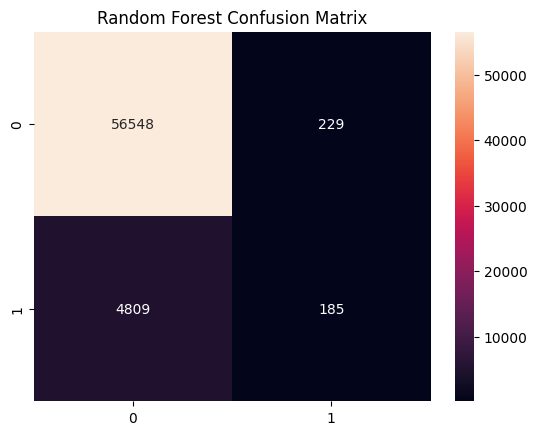

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
# Although Random Forest achieved higher overall accuracy (91.8%), it performed poorly in detecting heart disease cases (Recall = 0.04). Logistic Regression, despite lower accuracy (73.8%), achieved significantly higher recall (0.80) for positive cases, making it more suitable for medical screening applications.

In [25]:
# Take subset for tuning
X_tune = X_train[:50000]
y_tune = y_train[:50000]

In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 150],
    'max_depth': [None, 15],
    'min_samples_split': [2, 5]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_dist,
    n_iter=4,
    cv=2,
    scoring='recall',
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_tune, y_tune)

print("Best Parameters:", rf_random.best_params_)

Best Parameters: {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': 15}


In [27]:
best_rf = RandomForestClassifier(
    **rf_random.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

best_pred = best_rf.predict(X_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, best_pred))
print("\nClassification Report:\n", classification_report(y_test, best_pred))

Tuned RF Accuracy: 0.7966197730326529

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.81      0.88     56777
           1       0.23      0.67      0.35      4994

    accuracy                           0.80     61771
   macro avg       0.60      0.74      0.61     61771
weighted avg       0.91      0.80      0.84     61771



Although Random Forest achieved high initial accuracy, it failed to detect heart disease cases effectively. After hyperparameter tuning optimized for recall, the model significantly improved detection performance. Logistic Regression achieved the highest recall, making it suitable for medical screening applications where minimizing false negatives is critical.

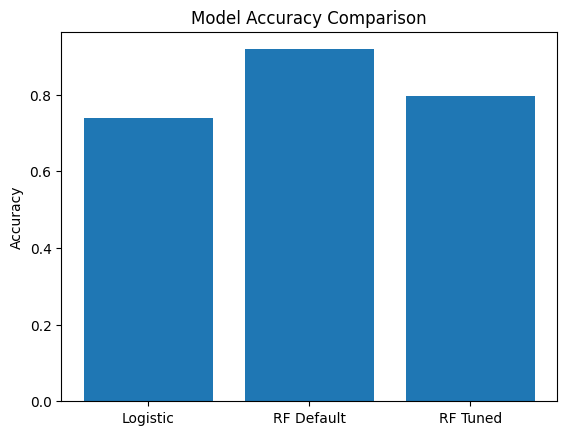

In [29]:
log_acc = accuracy_score(y_test, log_pred)
rf_default_acc = accuracy_score(y_test, rf_pred)
rf_tuned_acc = accuracy_score(y_test, best_pred)

models = ['Logistic', 'RF Default', 'RF Tuned']
accuracies = [log_acc, rf_default_acc, rf_tuned_acc]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [33]:
sample = X.iloc[[10]]   # keeps it as DataFrame
sample_scaled = scaler.transform(sample)

In [36]:
# ----- AI System Style Single Input Prediction -----

# Select a sample as DataFrame (NOT numpy array)
sample = X.iloc[[10]]   # double brackets keep it as DataFrame

# Scale the sample
sample_scaled = scaler.transform(sample)

# Predict using final model
prediction = best_rf.predict(sample_scaled)

# Display result
if prediction[0] == 1:
    print("⚠️ Prediction Result: High Risk of Heart Disease")
else:
    print("✅ Prediction Result: Low Risk of Heart Disease")

⚠️ Prediction Result: High Risk of Heart Disease
